# Spending Pattern analysis

# Improting Necessary librarires

In [41]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/customer-spending-dataset/customer_data.csv


In [42]:
df = pd.read_csv('/kaggle/input/customer-spending-dataset/customer_data.csv')

# Data Clearning/ Preprocessing

## Checking for null values

In [43]:
df.isnull().sum()

name                  0
age                   0
gender                0
education             0
income                0
country               0
purchase_frequency    0
spending              0
dtype: int64

In [44]:
df.head(10)

,name,age,gender,education,income,country,purchase_frequency,spending
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780
5,Charles Smith,24,Female,PhD,61444,Libyan Arab Jamahiriya,1.0,18072.200
6,Misty Moody,58,Male,PhD,78024,Italy,0.9,21511.080
7,Brian Kent,34,Male,High School,32225,Pakistan,0.7,6727.875
8,Stacie Ray,63,Male,PhD,63664,Venezuela,0.4,9273.280
9,Brian Townsend,64,Female,High School,45043,San Marino,1.0,16252.150


## Removing irrelevent feature

In [45]:
df.drop(['name'],axis=1,inplace=True)

## Inspecting Dataset

It's important to see how the data is distributed to check for any biases in the dataset

### Histogram plot for numeric features

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



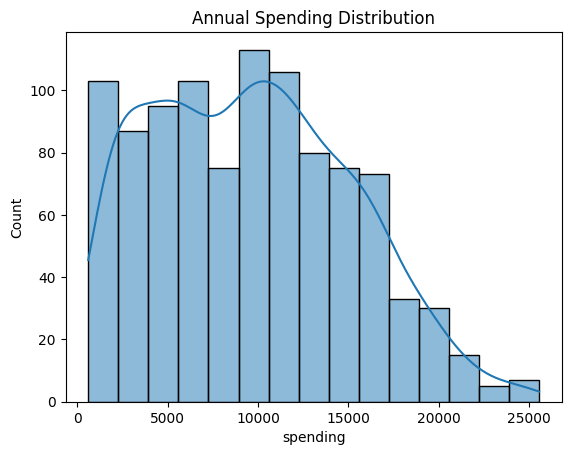

In [46]:
sns.histplot(df['spending'], kde=True)
plt.title("Annual Spending Distribution")
plt.show()

In [47]:

fig = px.choropleth(df.groupby('country')['spending'].sum().reset_index(),
                    locations='country',
                    locationmode='country names',
                    color='spending',
                    color_continuous_scale='Blues',
                    title='Total Spending by Country')
fig.show()


In [48]:
df['gender'].value_counts()

gender
Male      501
Female    499
Name: count, dtype: int64

In [49]:
gender_group = df.groupby('gender')
gender_group['income'].agg([
    'sum',
    'mean',
    'count'
])

,sum,mean,count
gender,,,
Female,29458669,59035.408818,499
Male,29819183,59519.327345,501
